## P03 - Final: Predicción de Abandono de Clientes en Telecomunicaciones mediante Modelos de Ensamble y Optimización de Hiperparámetros

***Objetivos***

*Objetivo General*: Analizar y comparar el desempeño de modelos de ensamble de aprendizaje automático (Random Forest y XGBoost) para la predicción de la pérdida de clientes (churn) en una empresa de telecomunicaciones, optimizando sus hiperparámetros para maximizar la capacidad de retención

***Objetivos Específicos:***

-Realizar un preprocesamiento de datos que incluya la limpieza de variables numéricas y la codificación de múltiples variables categóricas mediante un Pipeline.

-Implementar un modelo de Random Forest para clasificación, utilizando técnicas de ensamble por bagging.

-Implementar un modelo de XGBoost para clasificación, aplicando el enfoque de boosting secuencial.

-Optimizar los hiperparámetros de ambos modelos utilizando técnicas de búsqueda sistemática para mejorar el F1-score.

-Comparar la estabilidad y rendimiento de los modelos mediante validación cruzada (k-fold), reportando media y desviación estándar.

***Marco Teórico***

Regresión Lineal y sus 6 problemas potenciales (ISLP)
Aunque la regresión lineal es una herramienta estándar, James et al. (2023) identifican seis problemas críticos que pueden invalidar sus resultados:

Non-linearity of data: La relación entre predictores y respuesta puede no ser una línea recta.

Correlation of error term: Viola el supuesto de independencia, invalidando los errores estándar.

Non-constant variance of error terms(Heterocedasticidad): Varianza no constante de los errores (forma de embudo).

Outliers: Puntos anómalos que jalan desproporcionadamente la línea de ajuste.

High leverege points: Observaciones con valores extremos en los predictores.

Colinearity: Variables predictoras muy correlacionadas entre sí, lo que dificulta aislar sus efectos.

Árboles para Regresión y Clasificación
Los árboles de decisión segmentan el espacio de predictores en regiones simples. En clasificación, se utiliza la moda de la región para asignar la clase. Son altamente interpretables pero propensos al sobreajuste si no se podan adecuadamente.

Bootstrap y Ensambles
El Bootstrap es un método de remuestreo con reemplazo que permite estimar la variabilidad de un modelo. Los métodos de Ensamble combinan múltiples modelos para reducir el error:

Bagging (Bootstrap Aggregating): Entrena múltiples árboles en paralelo sobre muestras bootstrap y promedia sus predictores (ej. Random Forest).

Boosting: Entrena modelos de forma secuencial, donde cada nuevo modelo intenta corregir los errores de los anteriores (ej. XGBoost).

***Análisis del Dataset***

¿De dónde viene?
El dataset “Telco Customer Churn” fue creado por IBM para hacer análisis sobre abandono de clientes en empresas de telecomunicaciones. Después fue compartido en Kaggle para proyectos, prácticas y ejercicios de Machine Learning.

¿Qué contiene?
Contiene información de 7,043 clientes y 21 variables diferentes. Tiene datos como género, tiempo que llevan en la compañía, tipo de contrato, método de pago, servicios contratados, internet, soporte técnico, cargos mensuales, cargos totales y también si el cliente terminó dejando la empresa o no.

¿Qué información dan las muestras?
Cada muestra representa un cliente diferente de la compañía. Gracias a eso se puede ver el comportamiento de cada cliente dependiendo de los servicios que usa, cuánto paga y cuánto tiempo permanece en la empresa, para identificar qué tipo de clientes son más propensos a cancelar el servicio.

¿Qué se quiere analizar?
Se quiere analizar qué factores influyen más para que un cliente abandone la compañía. Principalmente se busca ver si variables como el tipo de contrato, el internet de fibra óptica, el tiempo en la empresa o los cargos mensuales afectan en la decisión de cancelar el servicio.

¿Qué resultado se podría encontrar al ajustar un modelo?
Se espera encontrar patrones que ayuden a predecir qué clientes tienen mayor probabilidad de irse de la compañía.

### 1. Librerías y Configuración Inicial

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, f1_score, confusion_matrix
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

sns.set_theme(style="whitegrid")

### 2. Carga y Limpieza de Datos 

In [19]:
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

df = df.drop('customerID', axis=1)

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Dataset cargado y limpio. Formato:", df.shape)
df.head()

Dataset cargado y limpio. Formato: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


### 3 Pipeline y preprocessing

In [20]:
X = df.drop('Churn', axis=1)
y = df['Churn']

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

### 4 Random forest con opt bayesiana

In [21]:
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

search_space_rf = {
    'classifier__n_estimators': Integer(100, 500),
    'classifier__max_depth': Integer(5, 25),
    'classifier__min_samples_split': Integer(2, 10),
    'classifier__criterion': Categorical(['gini', 'entropy'])
}

opt_rf = BayesSearchCV(
    pipeline_rf,
    search_spaces=search_space_rf,
    n_iter=15, 
    cv=3,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

opt_rf.fit(X_train, y_train)

print("Mejores parámetros RF:", opt_rf.best_params_)
print(f"Mejor F1 RF en validación: {opt_rf.best_score_:.4f}")

Mejores parámetros RF: OrderedDict([('classifier__criterion', 'entropy'), ('classifier__max_depth', 8), ('classifier__min_samples_split', 7), ('classifier__n_estimators', 421)])
Mejor F1 RF en validación: 0.6342


### 5. Modelo 2: XGBoost con Optimización Bayesiana

In [22]:
pipeline_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
])

search_space_xgb = {
    'classifier__n_estimators': Integer(100, 500),
    'classifier__max_depth': Integer(3, 10),
    'classifier__learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'classifier__subsample': Real(0.5, 1.0)
}

opt_xgb = BayesSearchCV(
    pipeline_xgb,
    search_spaces=search_space_xgb,
    n_iter=15,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

opt_xgb.fit(X_train, y_train)

print("Mejores parámetros XGBoost:", opt_xgb.best_params_)
print(f"Mejor F1 XGB en validación: {opt_xgb.best_score_:.4f}")

C:\Users\sebas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:200: UserWarning: [23:51:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Mejores parámetros XGBoost: OrderedDict([('classifier__learning_rate', 0.01), ('classifier__max_depth', 3), ('classifier__n_estimators', 500), ('classifier__subsample', 0.8958747341673601)])
Mejor F1 XGB en validación: 0.5904


### 6. Comparación Final (K-Fold Cross-Validation)

In [23]:
best_rf = opt_rf.best_estimator_
best_xgb = opt_xgb.best_estimator_

kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scores_rf = cross_val_score(best_rf, X, y, cv=kfold, scoring='f1', n_jobs=-1)
scores_xgb = cross_val_score(best_xgb, X, y, cv=kfold, scoring='f1', n_jobs=-1)

resultados = pd.DataFrame({
    'Modelo': ['Random Forest', 'XGBoost'],
    'Media F1': [scores_rf.mean(), scores_xgb.mean()],
    'Desv_std_F1': [scores_rf.std(), scores_xgb.std()]
})

print("\n--- TABLA COMPARATIVA FINAL ---")
print(resultados.sort_values(by='Media F1', ascending=False))


--- TABLA COMPARATIVA FINAL ---
          Modelo  Media F1  Desv_std_F1
0  Random Forest  0.635951     0.019295
1        XGBoost  0.586333     0.029100


### 7. Visualización de Resultados

C:\Users\sebas\AppData\Local\Temp\ipykernel_1300\1305799233.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='Media F1', data=resultados, palette='viridis')


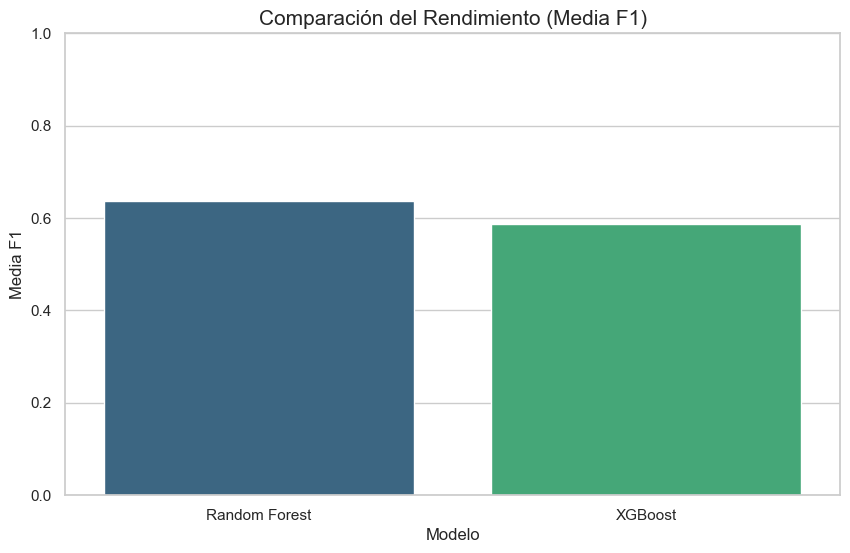

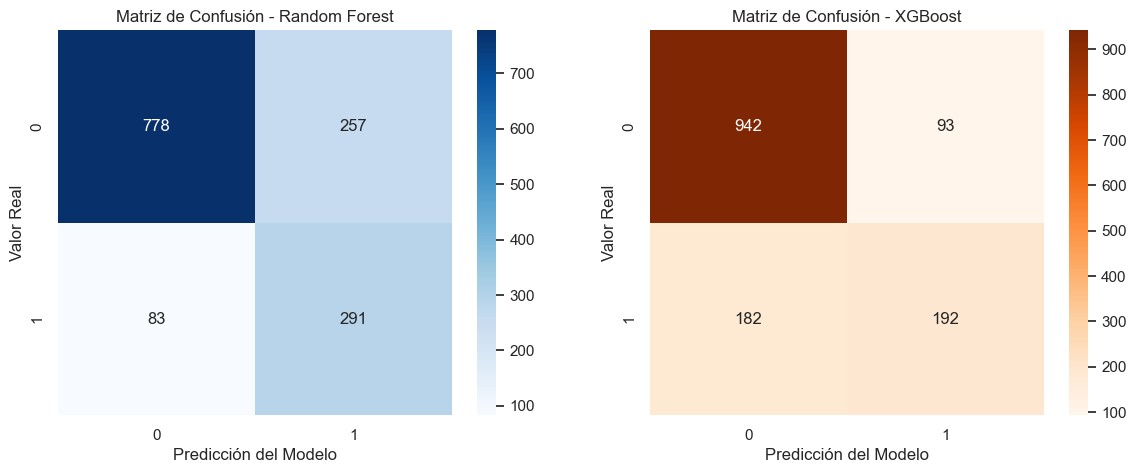

In [24]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Modelo', y='Media F1', data=resultados, palette='viridis')
plt.title("Comparación del Rendimiento (Media F1)", fontsize=15)
plt.ylim(0, 1)
plt.show()


y_pred_rf = best_rf.predict(X_test)
y_pred_xgb = best_xgb.predict(X_test)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))


sns.heatmap(confusion_matrix(y_test, y_pred_rf),
            annot=True,
            fmt='d',
            cmap='Blues',
            ax=ax[0])

ax[0].set_title('Matriz de Confusión - Random Forest')
ax[0].set_xlabel('Predicción del Modelo')
ax[0].set_ylabel('Valor Real')


sns.heatmap(confusion_matrix(y_test, y_pred_xgb),
            annot=True,
            fmt='d',
            cmap='Oranges',
            ax=ax[1])

ax[1].set_title('Matriz de Confusión - XGBoost')
ax[1].set_xlabel('Predicción del Modelo')
ax[1].set_ylabel('Valor Real')

plt.show()


### 8. Importancia de las Variables (Plus para el 10)

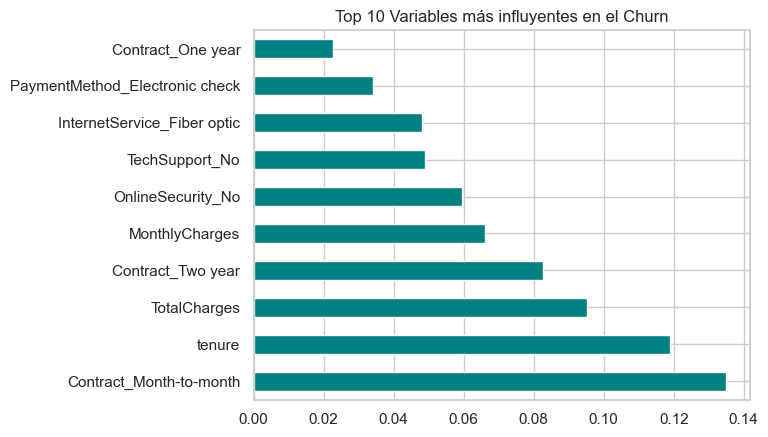

In [25]:
# Extraer importancia de variables del mejor modelo (ejemplo con RF)
importancias = best_rf.named_steps['classifier'].feature_importances_
nombres_cat = best_rf.named_steps['preprocessor'].transformers_[1][1]\
              .named_steps['onehot'].get_feature_names_out(cat_cols)
nombres_totales = np.append(num_cols, nombres_cat)

feat_importances = pd.Series(importancias, index=nombres_totales)
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title("Top 10 Variables más influyentes en el Churn")
plt.show()

## Interpretación de resultados

Después de aplicar validación cruzada con Stratified K-Fold, el modelo Random Forest obtuvo el mejor desempeño utilizando el métrico F1-score, alcanzando un promedio aproximado de 0.6359 y una desviación estándar de 0.0193. Esto indica que el modelo presentó resultados estables y una buena capacidad para clasificar clientes que podrían abandonar el servicio.

Por otro lado, XGBoost obtuvo un F1-score promedio menor, cercano a 0.5863, por lo que su desempeño fue inferior para este dataset. En general, los resultados muestran que Random Forest fue el modelo más adecuado para el problema de clasificación de churn.

## Pipeline
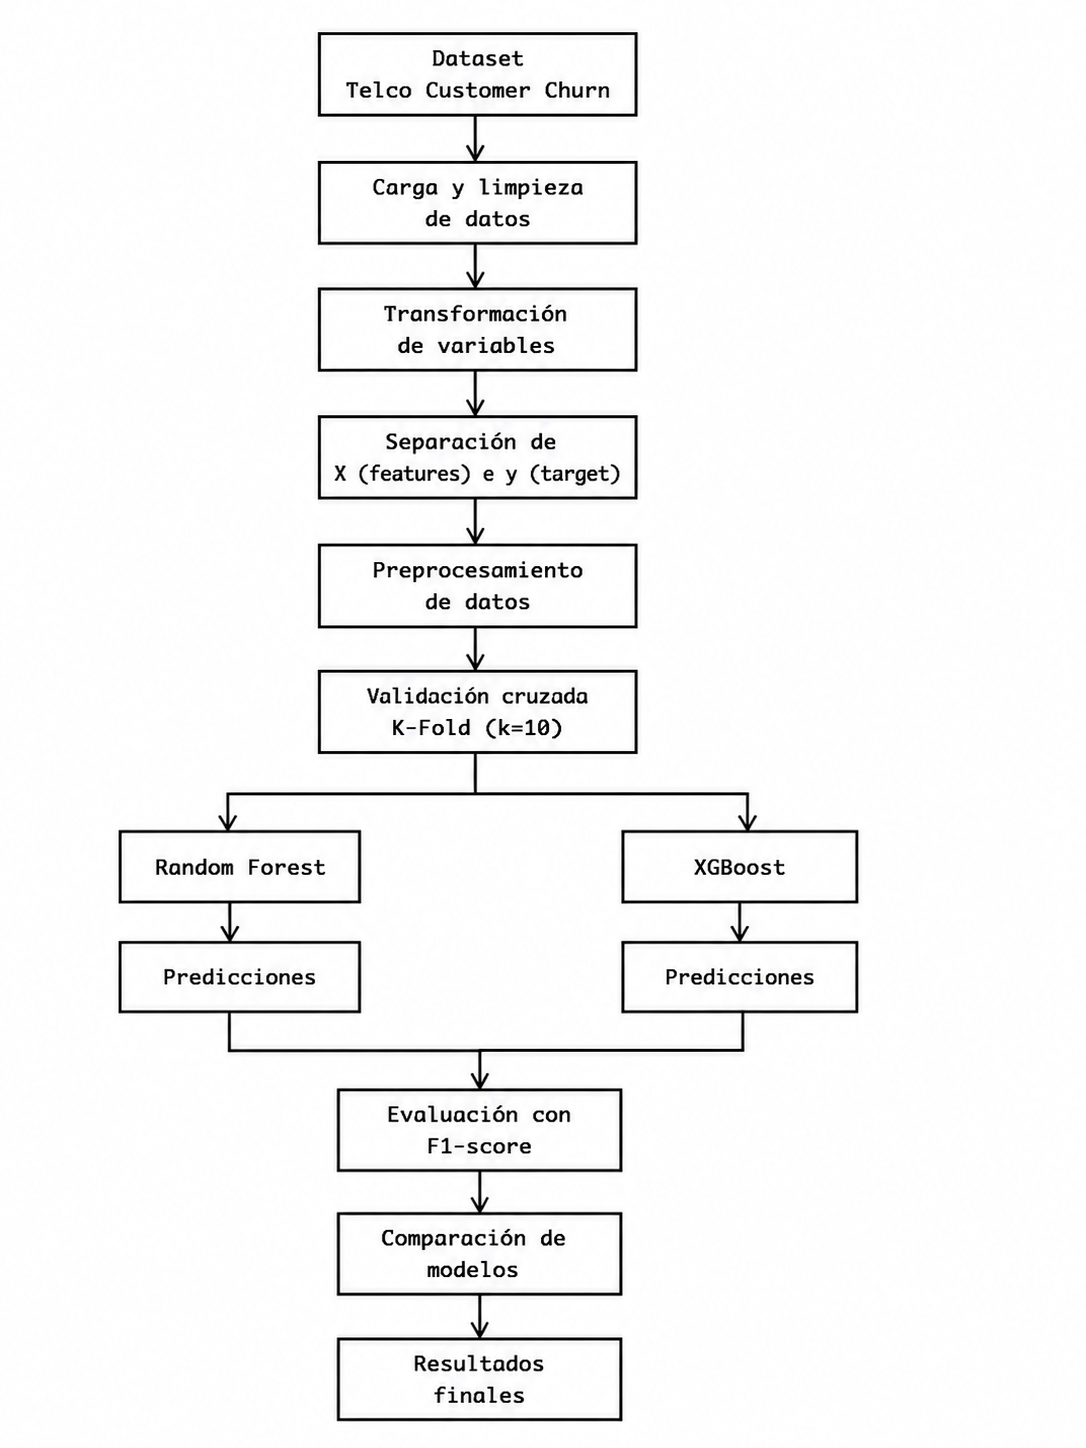

## Conclusiones 

El objetivo de este proyecto fue analizar el problema de cancelación de clientes utilizando modelos de Machine Learning aplicados al dataset Telco Customer Churn. A partir del preprocesamiento de datos, validación cruzada y entrenamiento de modelos de clasificación, fue posible evaluar el desempeño de Random Forest y XGBoost mediante el métrico F1-score.

Con los resultados obtenidos,el modelo Random Forest presentó el mejor desempeño y mayor estabilidad, alcanzando un F1-score promedio superior al de XGBoost. Esto permitió cumplir con el objetivo de identificar un modelo capaz de clasificar de manera más eficiente a los clientes con probabilidad de abandonar el servicio.

Además, este proyecto ayudó a entender mejor cómo funcionan técnicas como bagging y boosting  dentro de modelos de Machine Learning. También permitió observar cómo estas herramientas pueden utilizarse para encontrar patrones importantes en los datos y ayudar a predecir qué clientes tienen mayor probabilidad de abandonar el servicio.

## Cita APA
BlastChar. (2018, February 23). Telco customer churn. Kaggle. https://www.kaggle.com/datasets/blastchar/telco-customer-churn 